#### Confronto Metrice Validazione e Train Classificatori Baseline

Questo notebook confronta le prestazioni sul validation set dei due classificatori baseline: ResNet-50 ed EfficientNetB3

I dati di ingresso (metriche di validazione e log di training in formato CSV) vengono scaricati da Google Drive. Il notebook produce i seguenti output:

- tabella riassuntiva delle metriche principali (AUC, Accuracy, Precision, Recall, F1-score, soglia ottimale di Youden) con evidenziazione del modello migliore per ciascuna metrica
- bar chart comparativo delle metriche sul validation set
- heatmap del classification report per classe per entrambi i modelli
- curve di training e validation (Loss, AUC, Accuracy) per ciascuna fase di addestramento

In [12]:
import os
import sys

if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = '/content/drive/MyDrive/MammoDiffusion/'
else:
    print("Ambiente locale rilevato.")
    BASE_PATH = '../'

print(f"Percorso base: {BASE_PATH}")

Ambiente locale rilevato.
Percorso base: ../


#### Import librerie

In [13]:
import json
import gdown
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import re
import seaborn as sns
from pathlib import Path

#### Configurazione dei modelli e delle cartelle di output

Definisce i dizionari di configurazione per i due modelli baseline (`MODEL_A` → ResNet-50, `MODEL_B` → EfficientNetB3), ciascuno con l'ID Google Drive del file di metriche, l'etichetta testuale e il colore da usare nei grafici. Crea le cartelle di output per i risultati e le figure.


In [14]:
MODEL_A = {
    "drive_id": "1v7bfGdycvXcxyIVpSF5x2--943apw2KE",
    "label": "ResNet-50",                    
    "color": "#2196F3",
}

MODEL_B = {
    "drive_id": "13Ka-0tIG3_I2QOqUxO8HcC2MEZKLHA1X",
    "label": "EfficientNetB3",
    "color": "#FF5722",
}

OUTPUT_DIR = os.path.join(BASE_PATH, 'results', '05_confronto_metriche_val_classificatori')
FIGURES_DIR = os.path.join(OUTPUT_DIR, 'figures')
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)
print(f"Cartella output: {OUTPUT_DIR}")
print(f"Cartella figure: {FIGURES_DIR}")

Cartella output: ../results/05_confronto_metriche_val_classificatori
Cartella figure: ../results/05_confronto_metriche_val_classificatori/figures


#### Funzione di download e caricamento delle metriche di validazione

Definisce `download_metrics`: scarica da Google Drive il file `val_metrics.json` di ciascun modello (solo se non già presente in locale) e ne restituisce il contenuto come dizionario Python. Richiama la funzione per entrambi i modelli.


In [15]:
def download_metrics(config: dict, dest_dir: str) -> dict:
    dest_path = os.path.join(dest_dir, f"val_metrics_{config['label'].replace(' ', '_')}.json")
    
    if not os.path.isfile(dest_path):
        print(f"Scarico metriche per '{config['label']}' da Google Drive...")
        gdown.download(id=config["drive_id"], output=dest_path, quiet=False)
    else:
        print(f"File già presente per '{config['label']}', salto il download")
    
    with open(dest_path, 'r', encoding='utf-8') as f:
        return json.load(f)


metrics_a = download_metrics(MODEL_A, OUTPUT_DIR)
metrics_b = download_metrics(MODEL_B, OUTPUT_DIR)

print("\nMetriche caricate con successo")

Scarico metriche per 'ResNet-50' da Google Drive...


Downloading...
From: https://drive.google.com/uc?id=1v7bfGdycvXcxyIVpSF5x2--943apw2KE
To: /home/enzo/DeepLearning/MammoDiffusion/results/05_confronto_metriche_val_classificatori/val_metrics_ResNet-50.json
100%|██████████| 655/655 [00:00<00:00, 1.98MB/s]


Scarico metriche per 'EfficientNetB3' da Google Drive...


Downloading...
From: https://drive.google.com/uc?id=13Ka-0tIG3_I2QOqUxO8HcC2MEZKLHA1X
To: /home/enzo/DeepLearning/MammoDiffusion/results/05_confronto_metriche_val_classificatori/val_metrics_EfficientNetB3.json
100%|██████████| 665/665 [00:00<00:00, 1.97MB/s]


Metriche caricate con successo


#### Tabella riassuntiva di confronto

Vengono visualizzate le principali metriche e evidenziate le differenze

In [16]:
METRIC_KEYS = [
    ("auc",                "AUC"),
    ("accuracy",           "Accuracy"),
    ("precision_cancer",   "Precision (Cancro)"),
    ("recall_cancer",      "Recall (Cancro)"),
    ("f1_cancer",          "F1 (Cancro)"),
    ("optimal_threshold_youden", "Soglia ottimale (Youden)"),
]

rows = []
for key, label in METRIC_KEYS:
    val_a = metrics_a.get(key, "N/A")
    val_b = metrics_b.get(key, "N/A")
    delta = round(val_a - val_b, 4) if isinstance(val_a, (int, float)) and isinstance(val_b, (int, float)) else "N/A"
    rows.append({
        "Metrica": label,
        MODEL_A["label"]: val_a,
        MODEL_B["label"]: val_b,
        f"Delta ({MODEL_A['label']} - {MODEL_B['label']})": delta,
    })

df_compare = pd.DataFrame(rows)
df_compare = df_compare.set_index("Metrica")

highlight_keys = {"AUC", "Accuracy", "Precision (Cancro)", "Recall (Cancro)", "F1 (Cancro)"}

def highlight_best(row):
    if row.name not in highlight_keys:
        return [""] * len(row)
    try:
        a, b = float(row[MODEL_A["label"]]), float(row[MODEL_B["label"]])
        if a > b:
            return ["background-color: #d4edda", "background-color: #fff3cd", ""]
        elif b > a:
            return ["background-color: #fff3cd", "background-color: #d4edda", ""]
        else:
            return ["", "", ""]
    except (ValueError, TypeError):
        return [""] * len(row)

display(df_compare.style.apply(highlight_best, axis=1).format(precision=4))

,ResNet-50,EfficientNetB3,Delta (ResNet-50 - EfficientNetB3)
Metrica,,,
AUC,0.6562,0.6605,-0.0043
Accuracy,0.6201,0.5767,0.0434
Precision (Cancro),0.2615,0.2431,0.0184
Recall (Cancro),0.6986,0.7260,-0.0274
F1 (Cancro),0.3806,0.3643,0.0163
Soglia ottimale (Youden),0.4456,0.6148,-0.1692


#### Bar chart comparativo delle metriche di validazione

Genera un bar chart  che confronta visivamente AUC, Accuracy, Precision, Recall e F1-score (classe cancro) tra i due modelli. 


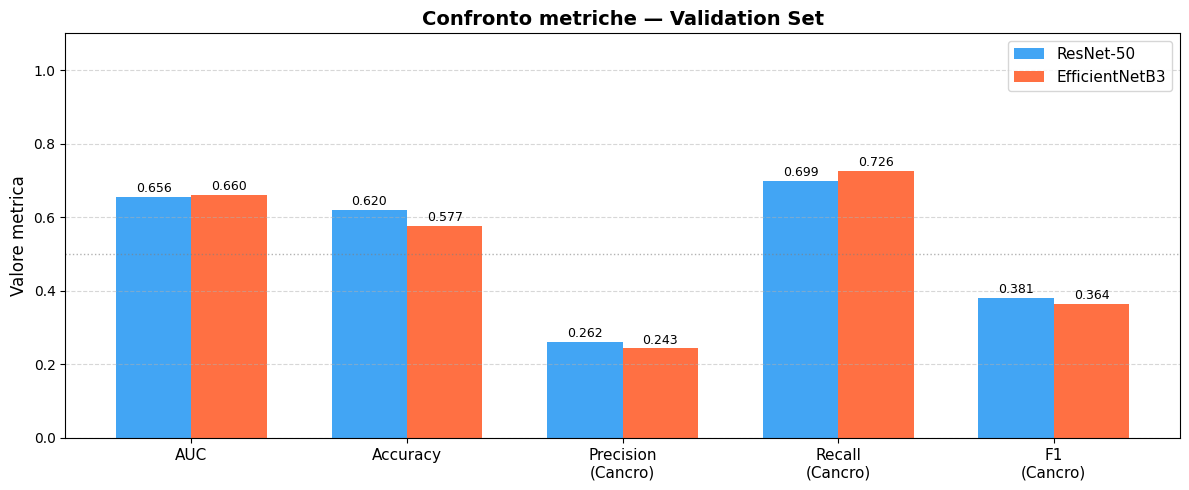

Grafico salvato in: ../results/05_confronto_metriche_val_classificatori/figures/confronto_metriche_barplot.png


In [17]:
PLOT_METRICS = [
    ("auc",              "AUC"),
    ("accuracy",         "Accuracy"),
    ("precision_cancer", "Precision\n(Cancro)"),
    ("recall_cancer",    "Recall\n(Cancro)"),
    ("f1_cancer",        "F1\n(Cancro)"),
]

keys   = [k for k, _ in PLOT_METRICS]
labels = [l for _, l in PLOT_METRICS]
vals_a = [metrics_a.get(k, 0) for k in keys]
vals_b = [metrics_b.get(k, 0) for k in keys]

x = np.arange(len(keys))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars_a = ax.bar(x - width / 2, vals_a, width, label=MODEL_A["label"], color=MODEL_A["color"], alpha=0.85)
bars_b = ax.bar(x + width / 2, vals_b, width, label=MODEL_B["label"], color=MODEL_B["color"], alpha=0.85)

for bar in bars_a:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=9)
for bar in bars_b:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Valore metrica", fontsize=12)
ax.set_title("Confronto metriche — Validation Set", fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.axhline(y=0.5, color='gray', linestyle=':', linewidth=1, alpha=0.6)

plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, 'confronto_metriche_barplot.png')
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Grafico salvato in: {fig_path}")

#### Heatmap del classification report per entrambi i modelli

 Produce una heatmap del classification report affiancata per i due modelli, con la soglia di Youden riportata nel titolo.


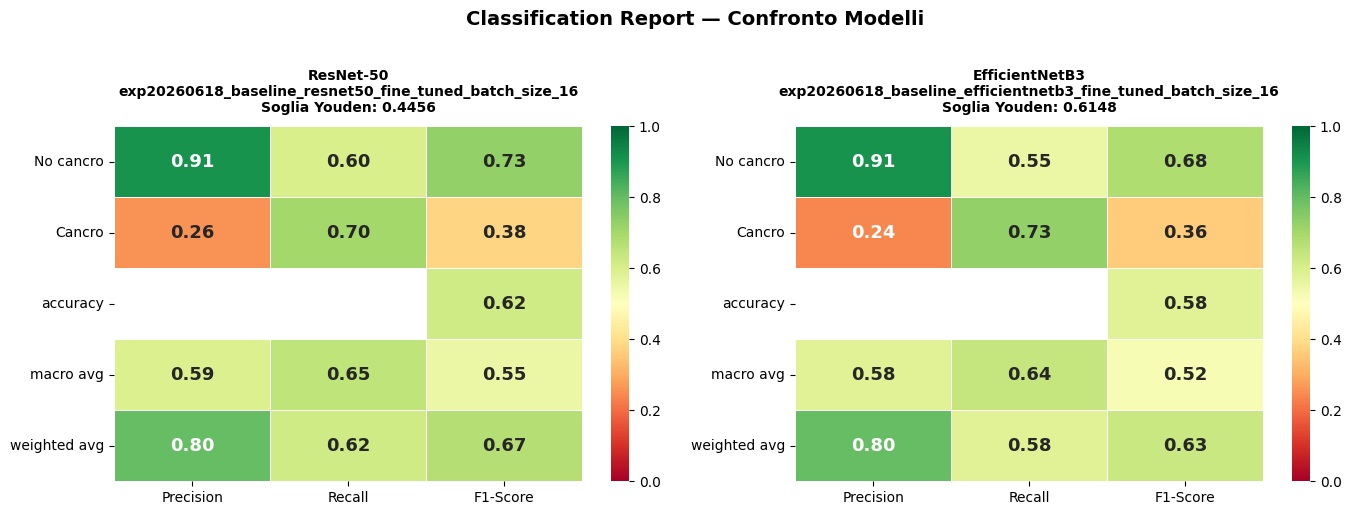

Heatmap salvata in: ../results/05_confronto_metriche_val_classificatori/figures/classification_report_heatmap.png


In [18]:
def parse_classification_report(report_str):
    lines = report_str.strip().split('\n')
    rows = []
    for line in lines:
        m = re.match(r'^\s*(.+?)\s{2,}(\d+\.\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)\s+(\d+)\s*$', line)
        if m:
            rows.append({
                'Classe': m.group(1).strip(),
                'Precision': float(m.group(2)),
                'Recall': float(m.group(3)),
                'F1-Score': float(m.group(4)),
                'Support': int(m.group(5)),
            })
        else:
            m2 = re.match(r'^\s*accuracy\s+(\d+\.\d+)\s+(\d+)\s*$', line)
            if m2:
                rows.append({
                    'Classe': 'accuracy',
                    'Precision': float('nan'),
                    'Recall': float('nan'),
                    'F1-Score': float(m2.group(1)),
                    'Support': int(m2.group(2)),
                })
    return pd.DataFrame(rows).set_index('Classe')


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (cfg, metrics) in zip(axes, [(MODEL_A, metrics_a), (MODEL_B, metrics_b)]):
    df = parse_classification_report(metrics.get("classification_report", ""))
    plot_df = df[['Precision', 'Recall', 'F1-Score']]

    annot = plot_df.copy().astype(object)
    for col in plot_df.columns:
        for idx in plot_df.index:
            v = plot_df.loc[idx, col]
            annot.loc[idx, col] = f'{v:.2f}' if not pd.isna(v) else ''

    sns.heatmap(
        plot_df,
        annot=annot,
        fmt='',
        cmap='RdYlGn',
        vmin=0, vmax=1,
        linewidths=0.5,
        linecolor='white',
        ax=ax,
        cbar=True,
        annot_kws={"size": 13, "weight": "bold"},
    )

    threshold = metrics.get('optimal_threshold_youden', 'N/A')
    thresh_str = f'{threshold:.4f}' if isinstance(threshold, float) else threshold
    ax.set_title(
        f"{cfg['label']}\n{metrics.get('experiment_name', 'N/A')}\nSoglia Youden: {thresh_str}",
        fontsize=10, fontweight='bold', pad=10,
    )
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=0)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle('Classification Report — Confronto Modelli', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
report_path = os.path.join(FIGURES_DIR, 'classification_report_heatmap.png')
fig.savefig(report_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Heatmap salvata in: {report_path}")

#### Configurazione degli ID Google Drive per i log di training

Aggiunge ai dizionari dei modelli gli ID Google Drive dei file CSV dei log di addestramento (Fase 1 — Custom Head, Fase 2 — Fine-Tuning) e crea la sottocartella `training_log` destinata a contenerli.


In [19]:
MODEL_A["log_fase1_id"] = "1jn891W8uq8zbCC4JcXcPqGltG7KXzKiF"   # training_log_fase1.csv  ResNet-50

MODEL_A["log_fase2_id"] = "1_h7VqoHCpMchmbCryV3686k4q1o-mBNN"   # training_log_fase2.csv  ResNet-50

MODEL_B["log_fase1_id"] = "1LFZi-9clIdmxZS78HnQvPo2_lBKfaBRx"   # training_log_fase1.csv  EfficientNetB3

MODEL_B["log_fase2_id"] = "18oVj_4xLbHfdchGznpeZ5UCf55DkUK5t"   # training_log_fase2.csv  EfficientNetB3

TRAINING_LOG_DIR = os.path.join(OUTPUT_DIR, "training_log")
os.makedirs(TRAINING_LOG_DIR, exist_ok=True)
print(f"Cartella log di training: {TRAINING_LOG_DIR}")

Cartella log di training: ../results/05_confronto_metriche_val_classificatori/training_log


#### Funzione di download e caricamento dei log di training

In [20]:
def download_log(config: dict, fase: int, dest_dir: str) -> pd.DataFrame:
    drive_id = config[f"log_fase{fase}_id"]
    label = config["label"].replace(" ", "_")
    dest_path = os.path.join(dest_dir, f"training_log_fase{fase}_{label}.csv")

    if not os.path.isfile(dest_path):
        print(f"Scarico log fase {fase} per '{config['label']}'...")
        gdown.download(id=drive_id, output=dest_path, quiet=False)
    else:
        print(f"Log fase {fase} per '{config['label']}' già presente, salto il download")

    return pd.read_csv(dest_path)


log_a1 = download_log(MODEL_A, 1, TRAINING_LOG_DIR)
log_a2 = download_log(MODEL_A, 2, TRAINING_LOG_DIR)
log_b1 = download_log(MODEL_B, 1, TRAINING_LOG_DIR)
log_b2 = download_log(MODEL_B, 2, TRAINING_LOG_DIR)

print("\nLog di training caricati con successo")

Scarico log fase 1 per 'ResNet-50'...


Downloading...
From: https://drive.google.com/uc?id=1jn891W8uq8zbCC4JcXcPqGltG7KXzKiF
To: /home/enzo/DeepLearning/MammoDiffusion/results/05_confronto_metriche_val_classificatori/training_log/training_log_fase1_ResNet-50.csv
100%|██████████| 3.01k/3.01k [00:00<00:00, 4.15MB/s]


Scarico log fase 2 per 'ResNet-50'...


Downloading...
From: https://drive.google.com/uc?id=1_h7VqoHCpMchmbCryV3686k4q1o-mBNN
To: /home/enzo/DeepLearning/MammoDiffusion/results/05_confronto_metriche_val_classificatori/training_log/training_log_fase2_ResNet-50.csv
100%|██████████| 2.28k/2.28k [00:00<00:00, 4.92MB/s]


Scarico log fase 1 per 'EfficientNetB3'...


Downloading...
From: https://drive.google.com/uc?id=1LFZi-9clIdmxZS78HnQvPo2_lBKfaBRx
To: /home/enzo/DeepLearning/MammoDiffusion/results/05_confronto_metriche_val_classificatori/training_log/training_log_fase1_EfficientNetB3.csv
100%|██████████| 2.03k/2.03k [00:00<00:00, 4.95MB/s]


Scarico log fase 2 per 'EfficientNetB3'...


Downloading...
From: https://drive.google.com/uc?id=18oVj_4xLbHfdchGznpeZ5UCf55DkUK5t
To: /home/enzo/DeepLearning/MammoDiffusion/results/05_confronto_metriche_val_classificatori/training_log/training_log_fase2_EfficientNetB3.csv
100%|██████████| 1.42k/1.42k [00:00<00:00, 2.92MB/s]


Log di training caricati con successo


#### Curve di training e validation per fase di addestramento

Per ciascuna delle due fasi genera tre grafici affiancati (Loss, AUC, Accuracy) che sovrappone le curve di training e validation dei due modelli, consentendo il confronto della dinamica di convergenza


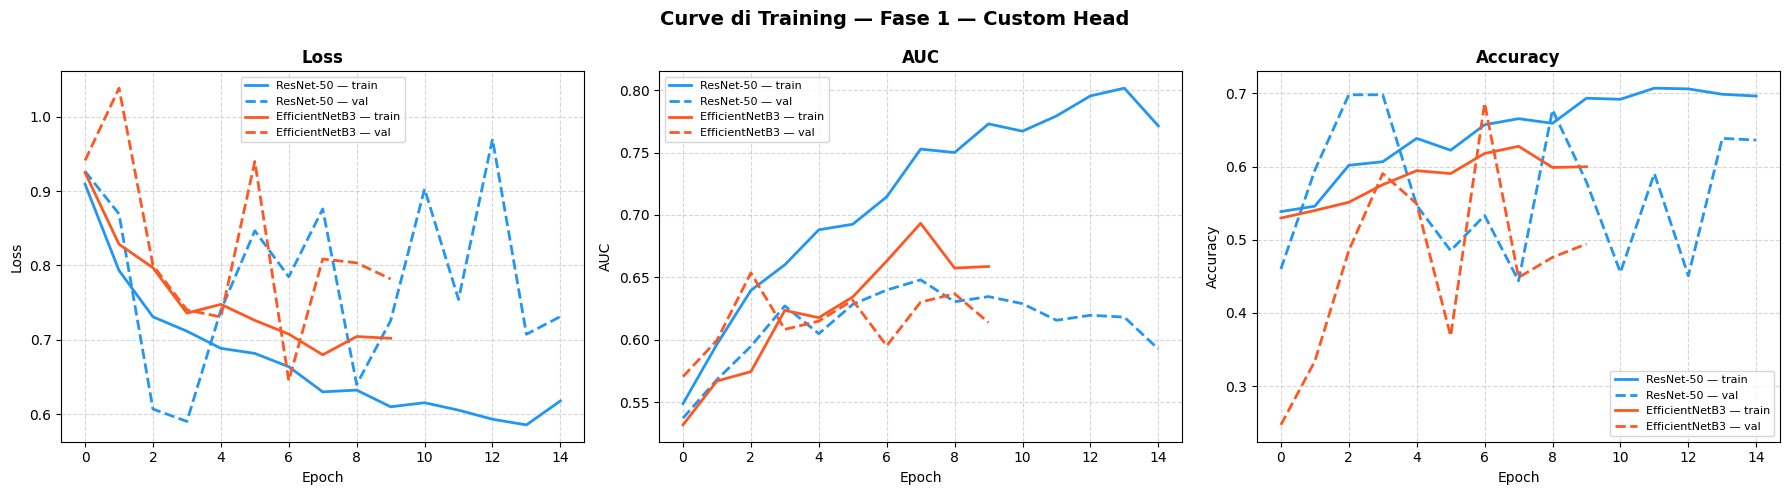

Grafico fase 1 salvato in: ../results/05_confronto_metriche_val_classificatori/figures/training_log_fase1.png


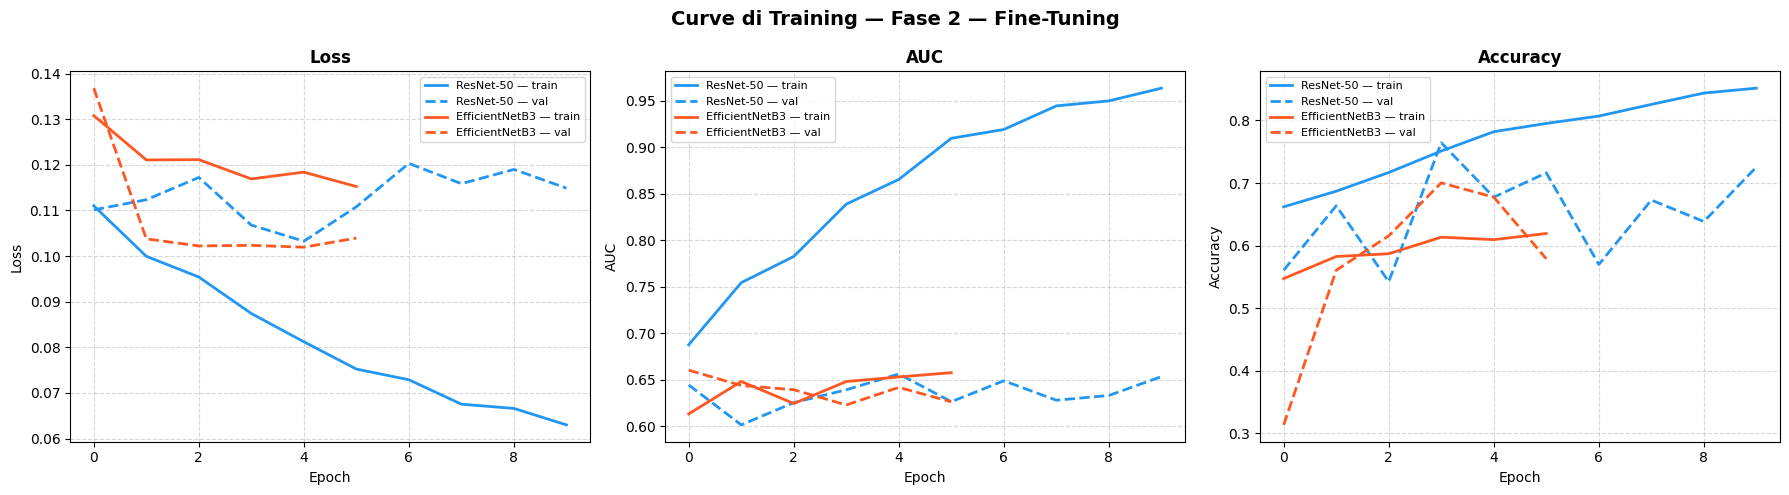

Grafico fase 2 salvato in: ../results/05_confronto_metriche_val_classificatori/figures/training_log_fase2.png


In [21]:
LOG_METRICS = [
    ("loss",     "val_loss",     "Loss"),
    ("auc",      "val_auc",      "AUC"),
    ("accuracy", "val_accuracy", "Accuracy"),
]

FASE_LABELS = {1: "Fase 1 — Custom Head", 2: "Fase 2 — Fine-Tuning"}

for fase, (log_a, log_b) in enumerate([(log_a1, log_b1), (log_a2, log_b2)], start=1):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Curve di Training — {FASE_LABELS[fase]}", fontsize=14, fontweight='bold')

    for ax, (train_col, val_col, metric_label) in zip(axes, LOG_METRICS):
        ax.plot(log_a["epoch"], log_a[train_col],
                color=MODEL_A["color"], linewidth=2, linestyle="-",
                label=f"{MODEL_A['label']} — train")
        ax.plot(log_a["epoch"], log_a[val_col],
                color=MODEL_A["color"], linewidth=2, linestyle="--",
                label=f"{MODEL_A['label']} — val")

        ax.plot(log_b["epoch"], log_b[train_col],
                color=MODEL_B["color"], linewidth=2, linestyle="-",
                label=f"{MODEL_B['label']} — train")
        ax.plot(log_b["epoch"], log_b[val_col],
                color=MODEL_B["color"], linewidth=2, linestyle="--",
                label=f"{MODEL_B['label']} — val")

        ax.set_title(metric_label, fontsize=12, fontweight="bold")
        ax.set_xlabel("Epoch", fontsize=10)
        ax.set_ylabel(metric_label, fontsize=10)
        ax.legend(fontsize=8)
        ax.grid(linestyle="--", alpha=0.5)

    plt.tight_layout()
    log_fig_path = os.path.join(FIGURES_DIR, f"training_log_fase{fase}.png")
    fig.savefig(log_fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Grafico fase {fase} salvato in: {log_fig_path}")